In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from deep_translator import GoogleTranslator
import seaborn as sns

In [21]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/LogisticsDataset/ActualDF")

In [22]:
df

,id,year,month,product,subdistrict_origin,district_origin,province_origin,subdistrict_destination,district_destination,province_destination,trips,shipping,average_distance,average_duration,average_speed
0,1,2025,January,paddy,ตาลสุม,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,405,9033,21.43,32.66,39.37
1,2,2025,January,paddy,พระอาจารย์,องครักษ์,Nakhon Nayok,ท่าสะอ้าน,บางปะกง,Chachoengsao,403,8981,63.93,91.61,41.87
2,3,2025,January,paddy,คำหว้า,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,384,8567,21.89,39.93,32.89
3,4,2025,January,paddy,วังม้า,ลาดยาว,Nakhon Sawan,ท่าฉนวน,มโนรมย์,Chai Nat,331,7376,67.10,84.94,47.40
4,5,2025,January,paddy,เตย,ม่วงสามสิบ,Ubon Ratchathani,ยางโยภาพ,ม่วงสามสิบ,Ubon Ratchathani,320,7143,18.50,26.89,41.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346966,346967,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,สุรศักดิ์,ศรีราชา,Chonburi,1,17,18.61,52.88,21.12
346967,346968,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,ไร่ส้ม,เมืองเพชรบุรี,Phetchaburi,1,17,236.98,332.48,42.77
346968,346969,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,บางแก้ว,เมืองสมุทรสงคราม,Samut Songkhram,1,17,177.05,245.00,43.36
346969,346970,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,คันนายาว,เขตคันนายาว,Bangkok,1,17,105.57,156.45,40.49


In [23]:
df.describe()

,id,year,trips,shipping,average_distance,average_duration,average_speed
count,346971.000000,346971.0,346971.000000,346971.000000,346971.000000,346971.000000,346971.000000
mean,173486.000000,2025.0,28.031945,776.947598,121.397510,156.876851,43.930749
std,100162.044463,0.0,163.843404,4922.222475,137.645385,175.312006,9.426172
min,1.000000,2025.0,1.000000,6.000000,3.000000,4.500000,15.000000
25%,86743.500000,2025.0,2.000000,40.000000,29.120000,44.960000,38.060000
50%,173486.000000,2025.0,5.000000,121.000000,74.950000,99.540000,45.000000
75%,260228.500000,2025.0,15.000000,369.000000,158.125000,199.210000,50.620000
max,346971.000000,2025.0,29978.000000,899332.000000,1480.180000,4444.170000,65.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346971 entries, 0 to 346970
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       346971 non-null  int64  
 1   year                     346971 non-null  int64  
 2   month                    346971 non-null  object 
 3   product                  346971 non-null  object 
 4   subdistrict_origin       346971 non-null  object 
 5   district_origin          346971 non-null  object 
 6   province_origin          346971 non-null  object 
 7   subdistrict_destination  346971 non-null  object 
 8   district_destination     346971 non-null  object 
 9   province_destination     346971 non-null  object 
 10  trips                    346971 non-null  int64  
 11  shipping                 346971 non-null  int64  
 12  average_distance         346971 non-null  float64
 13  average_duration         346971 non-null  float64
 14  aver

In [25]:
print(df.nunique())

id                         346971
year                            1
month                           5
product                        21
subdistrict_origin           4138
district_origin               877
province_origin                77
subdistrict_destination      5447
district_destination          917
province_destination           77
trips                        1644
shipping                     8753
average_distance            48140
average_duration            55370
average_speed                4995
dtype: int64


In [26]:
# convert Thai Calendar to Gregorian
df['year'] = df['year'] - 543
df["year"] = df["year"].astype(str)

### Fixing Automatic Translations

In [27]:
df["province_destination"].sort_values().unique()

array(['Amnat Charoen', 'Ang Thong', 'Ayutthaya', 'Bangkok', 'Bueng Kan',
       'Buriram', 'Chachoengsao', 'Chai Nat', 'Chaiyaphum', 'Chanthaburi',
       'Chiang Mai', 'Chiang Rai', 'Chonburi', 'Chumphon', 'Kalasin',
       'Kamphaeng Phet', 'Kanchanaburi', 'Khon Kaen', 'Krabi', 'Lampang',
       'Lamphun', 'Loei', 'Lop Buri', 'Mae Hong Son', 'Maha Sarakham',
       'Mukdahan', 'Nakhon Nayok', 'Nakhon Pathom', 'Nakhon Phanom',
       'Nakhon Ratchasima', 'Nakhon Sawan', 'Nakhon Si Thammarat', 'Nan',
       'Narathiwat', 'Nong Bua Lamphu', 'Nong Khai', 'Nonthaburi',
       'Pathum Thani', 'Pattani', 'Phang Nga', 'Phatthalung', 'Phayao',
       'Phetchabun', 'Phetchaburi', 'Phichit', 'Phitsanulok', 'Phrae',
       'Phuket', 'Prachin Buri', 'Prachuap Khiri Khan', 'Ranong',
       'Ratchaburi', 'Rayong', 'Roi Et', 'Sa Kaeo', 'Sakon Nakhon',
       'Samut Prakan', 'Samut Sakhon', 'Samut Songkhram', 'Saraburi',
       'Satun', 'Si Sa Ket', 'Sing Buri', 'Songkhla', 'Sukhothai',
       'Suph

In [28]:
province_fix = {
    "Sword": "Tak",
    "at all": "Phrae",
    "spread": "Krabi",
    "dry": "Loei",
    "Phangnga": "Phang Nga"
}

df["province_destination"] = df["province_destination"].replace(province_fix)
df["province_origin"] = df["province_origin"].replace(province_fix)

In [29]:
origin_lookup = (
    pd.DataFrame({
        "Thai": df_th["district_origin"],
        "English": df["district_origin"]
    })
    .drop_duplicates()
    .sort_values("Thai")
)

origin_lookup.to_excel(
    "origin_district_lookup.xlsx",
    index=False
)

In [30]:
df.head(20)

,id,year,month,product,subdistrict_origin,district_origin,province_origin,subdistrict_destination,district_destination,province_destination,trips,shipping,average_distance,average_duration,average_speed
0,1,1482,January,paddy,ตาลสุม,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,405,9033,21.43,32.66,39.37
1,2,1482,January,paddy,พระอาจารย์,องครักษ์,Nakhon Nayok,ท่าสะอ้าน,บางปะกง,Chachoengsao,403,8981,63.93,91.61,41.87
2,3,1482,January,paddy,คำหว้า,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,384,8567,21.89,39.93,32.89
3,4,1482,January,paddy,วังม้า,ลาดยาว,Nakhon Sawan,ท่าฉนวน,มโนรมย์,Chai Nat,331,7376,67.10,84.94,47.40
4,5,1482,January,paddy,เตย,ม่วงสามสิบ,Ubon Ratchathani,ยางโยภาพ,ม่วงสามสิบ,Ubon Ratchathani,320,7143,18.50,26.89,41.28
5,6,1482,January,paddy,วังม้า,ลาดยาว,Nakhon Sawan,ดงเสือเหลือง,โพธิ์ประทับช้าง,Phichit,316,7040,94.18,115.27,49.02
6,7,1482,January,paddy,ศีรษะกระบือ,องครักษ์,Nakhon Nayok,บางลูกเสือ,องครักษ์,Nakhon Nayok,262,5849,11.83,25.17,28.20
7,8,1482,January,paddy,ลาดยาว,ลาดยาว,Nakhon Sawan,สร้อยทอง,ตาคลี,Nakhon Sawan,247,5513,128.29,151.32,50.87
8,9,1482,January,paddy,แม่ทะ,แม่ทะ,Lampang,สมอแข,เมืองพิษณุโลก,Phitsanulok,229,5099,222.72,257.62,51.87
9,10,1482,January,paddy,ทุ่งเทิง,เดชอุดม,Ubon Ratchathani,น้ำอ้อม,เกษตรวิสัย,Roi Et,196,4374,265.91,336.79,47.37


### EDA

In [31]:
df.duplicated().sum()

np.int64(0)

#### Distribution Analysis

In [32]:
numerical_features = df.select_dtypes(include=('int64','float64')).columns
categorical_features = df.select_dtypes(include='object').columns

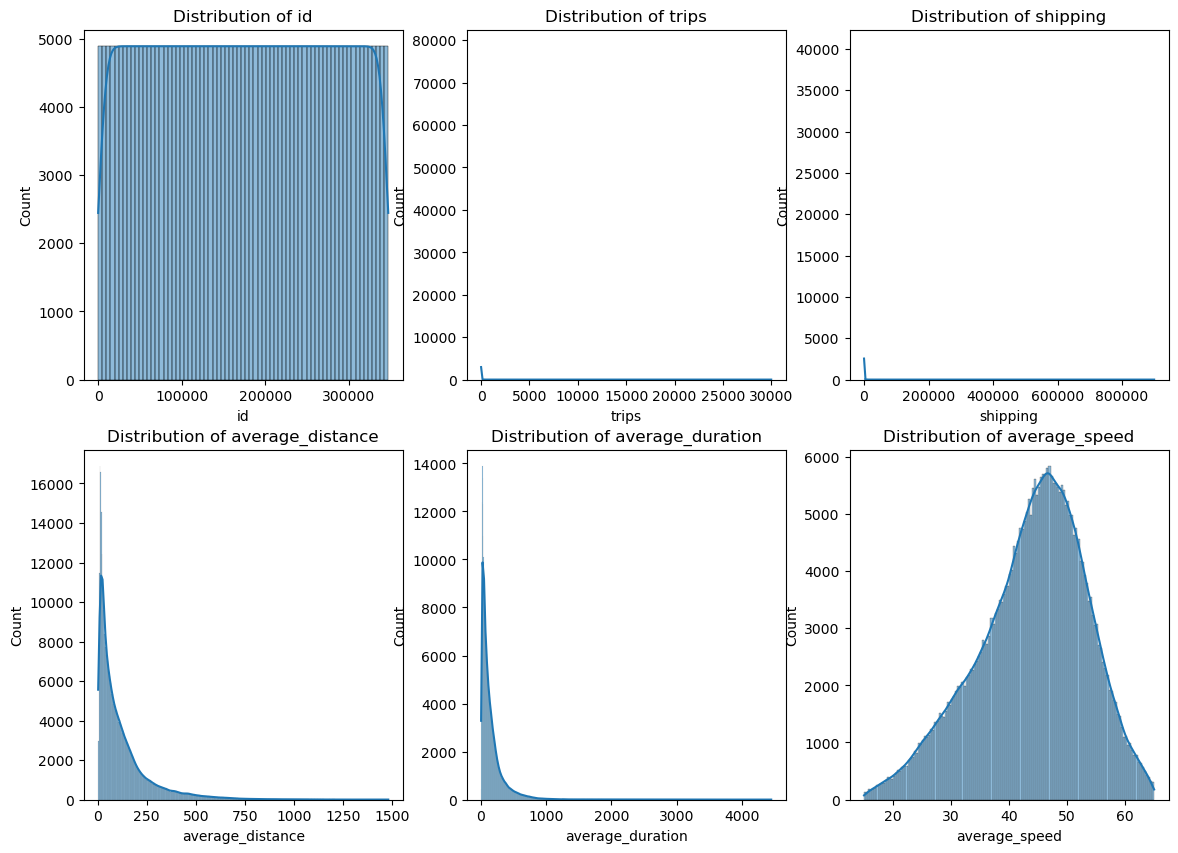

In [33]:
fig, axes = plt.subplots(2,3, figsize = (14,10))
axes = axes.flatten()

for i, j in enumerate(numerical_features):
    sns.histplot(
        df[j],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {j}")

plt.tight_layout
plt.show()

#### Outlier Analysis

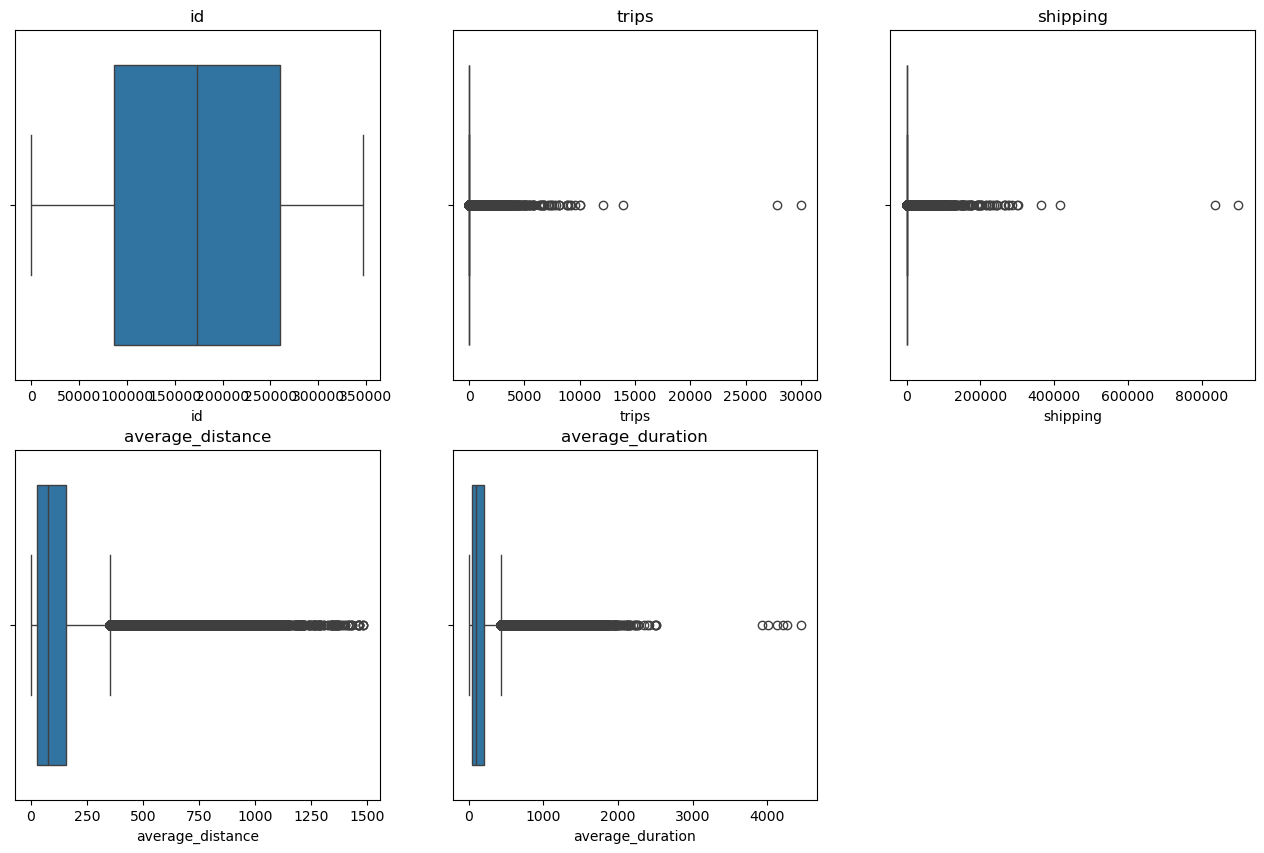

In [37]:
fig, axes = plt.subplots(2,3,figsize=(16,10))

axes=axes.flatten()


for i, col in enumerate(numerical_features):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    
    axes[i].set_title(col)

fig.delaxes(axes[-1])
plt.tight_layout
plt.show()

#### Correlation Analysis

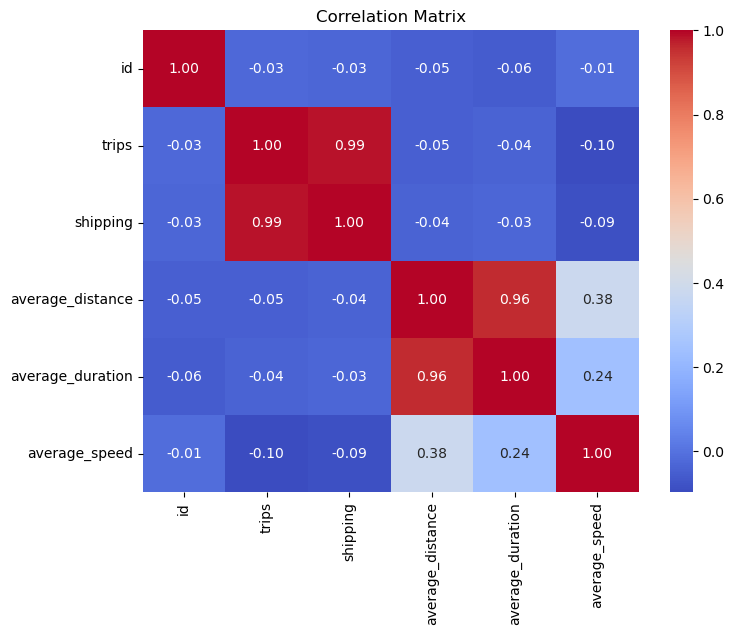

In [43]:
corr = df[numerical_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

#### Province Analysis

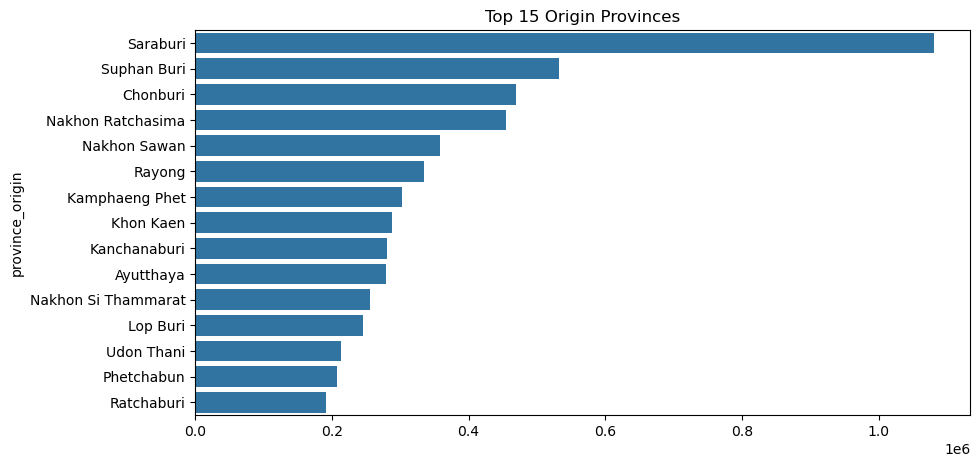

In [44]:
origin = (
    df.groupby("province_origin")["trips"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=origin.values,
    y=origin.index
)

plt.title("Top 15 Origin Provinces")

plt.show()

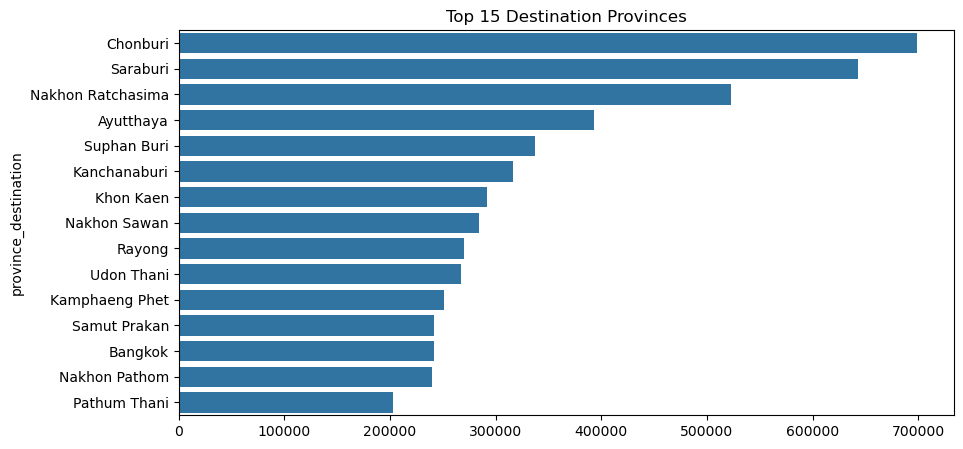

In [45]:
origin = (
    df.groupby("province_destination")["trips"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=origin.values,
    y=origin.index
)

plt.title("Top 15 Destination Provinces")

plt.show()

#### Product Analysis

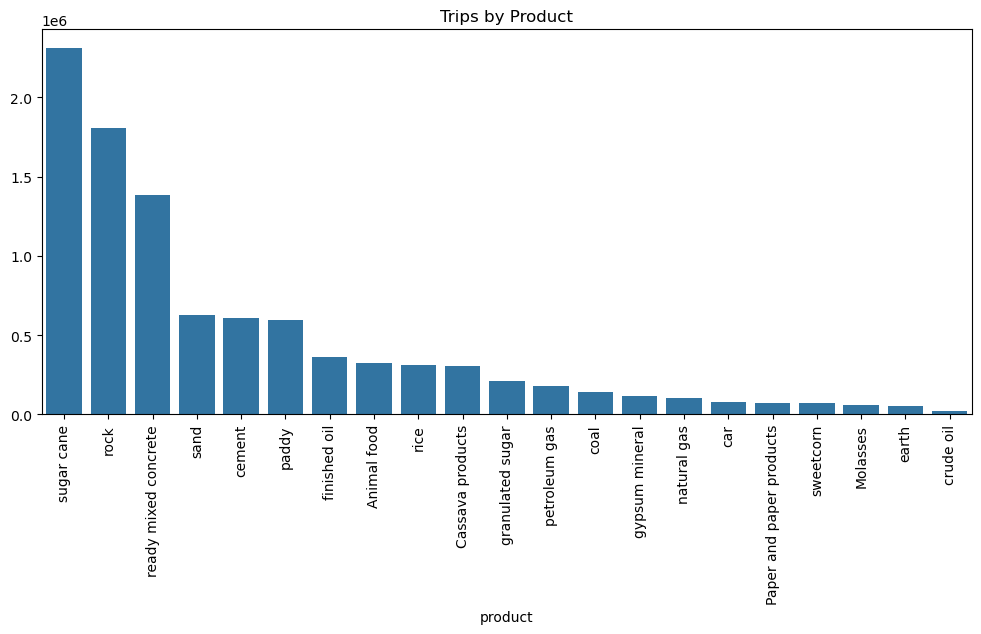

In [46]:
product_trips = (
    df.groupby('product')['trips']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=product_trips.index,
    y=product_trips.values
)

plt.xticks(rotation=90)

plt.title("Trips by Product")

plt.show()

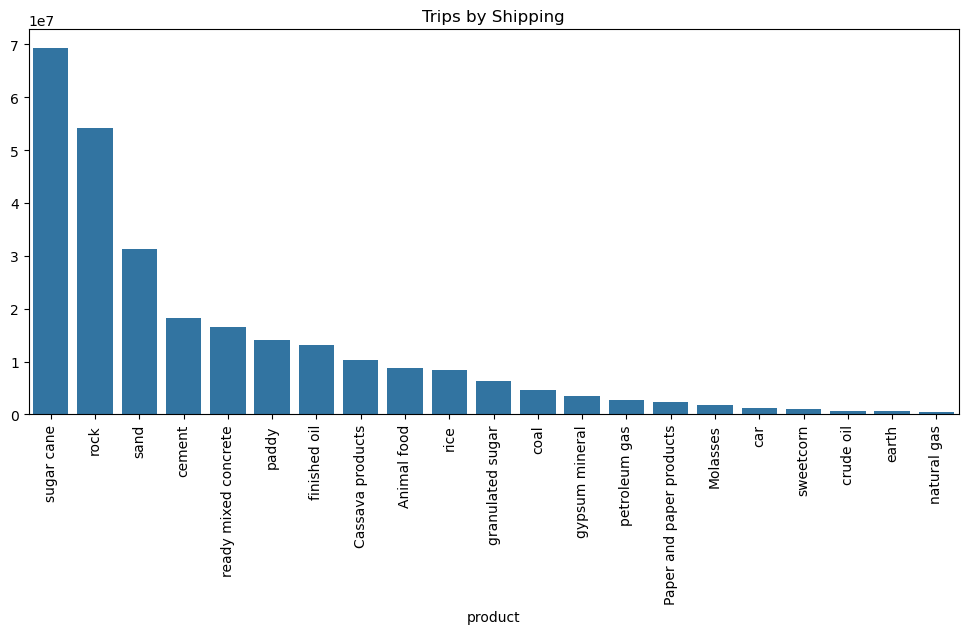

In [47]:
product_trips = (
    df.groupby('product')['shipping']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=product_trips.index,
    y=product_trips.values
)

plt.xticks(rotation=90)

plt.title("Trips by Shipping")

plt.show()

#### Monthly Trend - Any Seasonal Change?

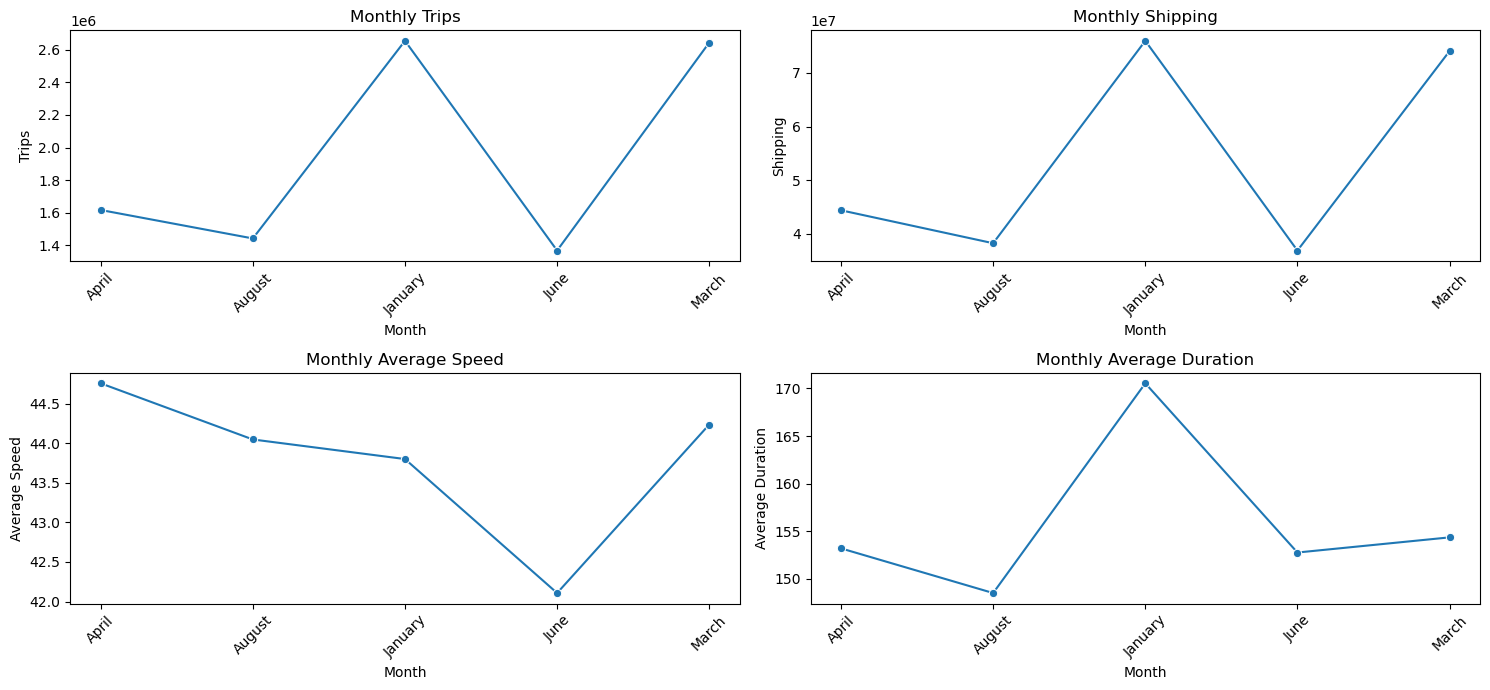

In [54]:
monthly_features = [
    "trips",
    "shipping",
    "average_speed",
    "average_duration"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(monthly_features):

    monthly = (
        df.groupby("month")[col]
          .sum() if col in ["trips", "shipping"]
        else df.groupby("month")[col]
              .mean()
    )

    sns.lineplot(
        x=monthly.index,
        y=monthly.values,
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Monthly {col.replace('_',' ').title()}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel(col.replace("_"," ").title())
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Route Analysis 

In [55]:
df['Route'] = (
    df['province_origin'] + " -> " + df['province_destination']
)

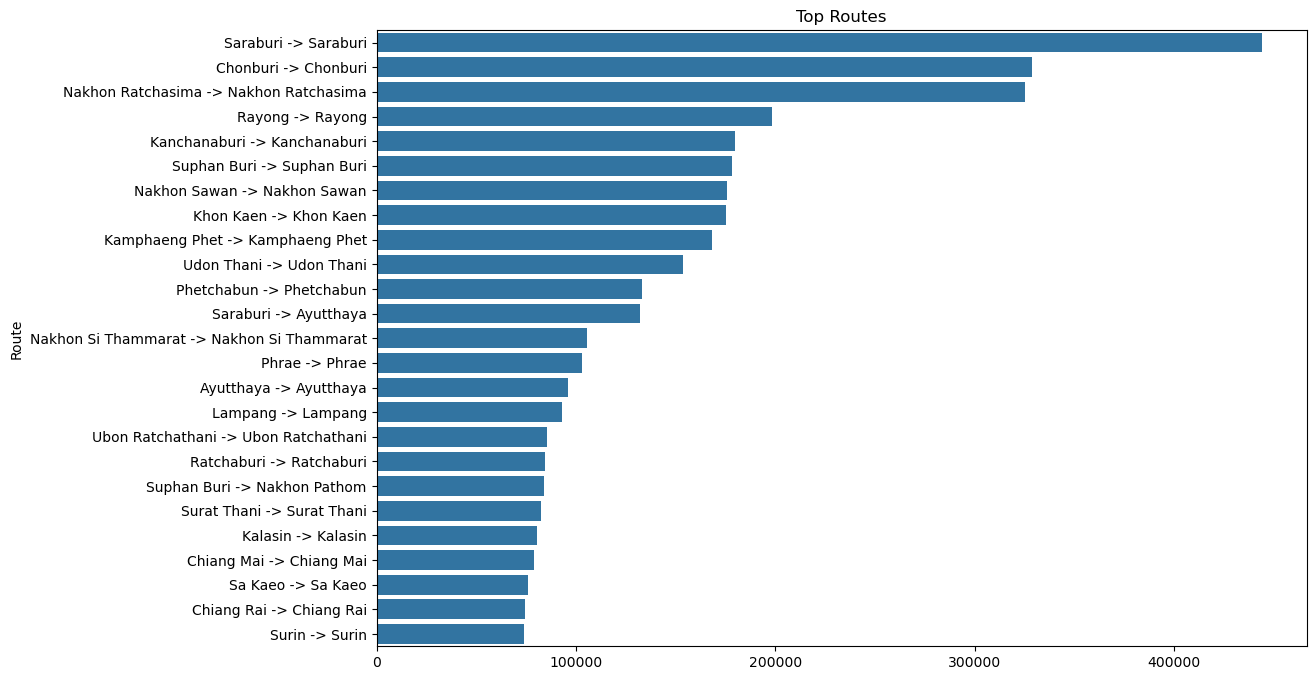

In [62]:
routes = (
    df.groupby("Route")['trips']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=routes.values,
    y=routes.index
)

plt.title("Top Routes")
plt.show()

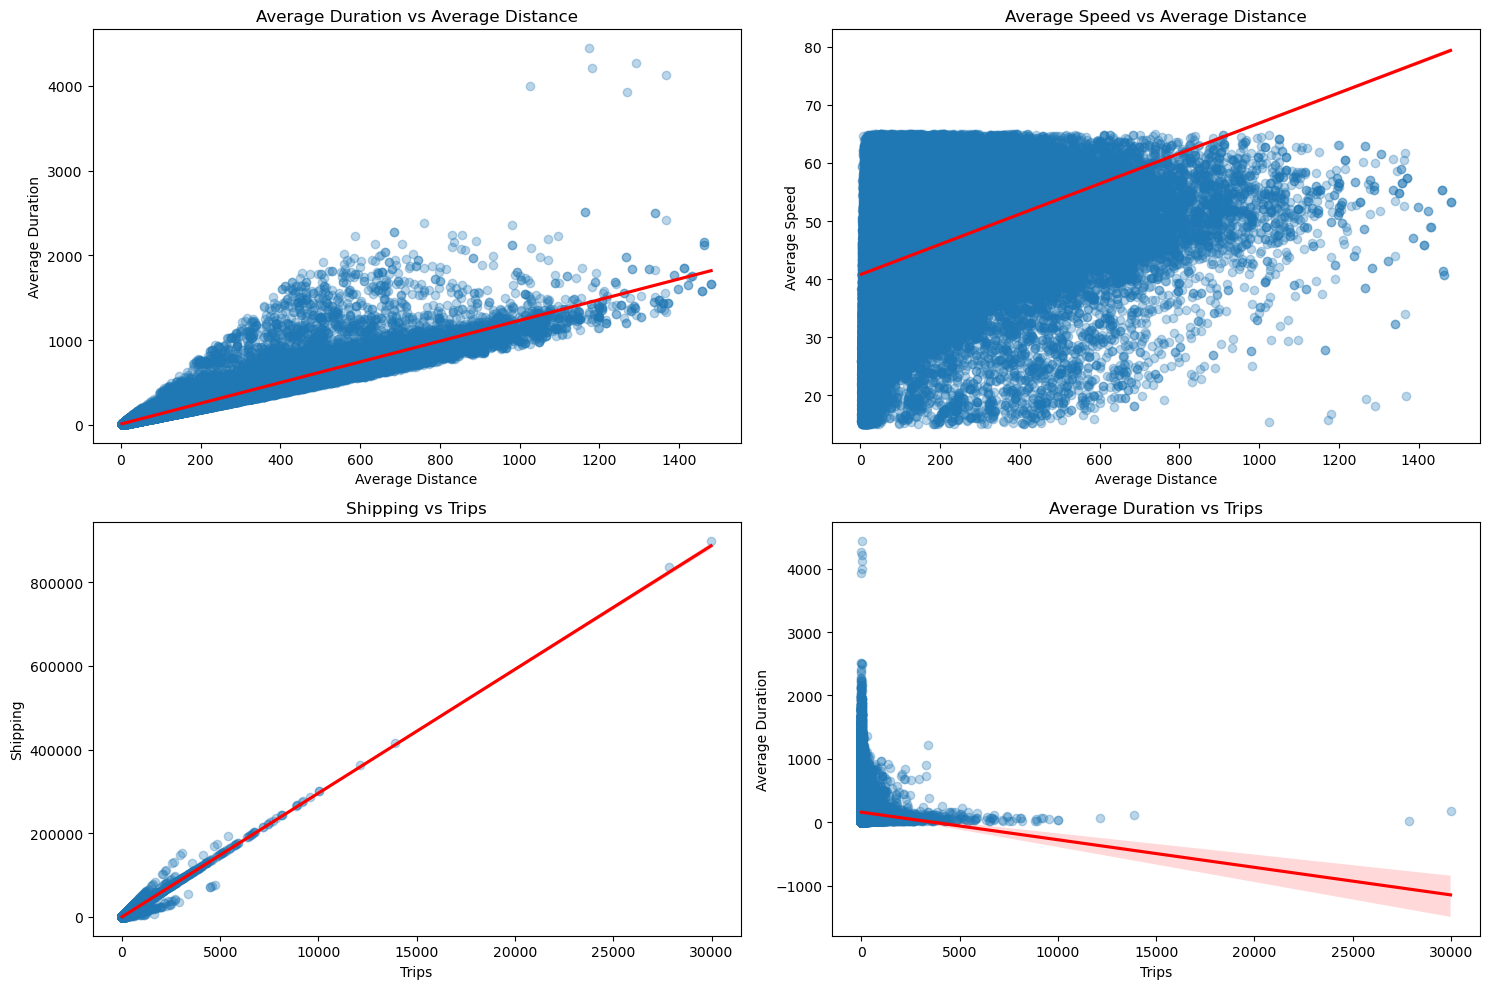

In [66]:
scatter_pairs = [
    ("average_distance", "average_duration"),
    ("average_distance", "average_speed"),
    ("trips", "shipping"),
    ("trips", "average_duration")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(scatter_pairs):

    sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[i]
)

    axes[i].set_title(f"{y.replace('_',' ').title()} vs {x.replace('_',' ').title()}")
    axes[i].set_xlabel(x.replace("_"," ").title())
    axes[i].set_ylabel(y.replace("_"," ").title())

plt.tight_layout()
plt.show()